<a href="https://colab.research.google.com/github/jiafenggang/Algo_F/blob/master/synthmorph_shapes_2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This demo trains a neural network for deformable image registration without
# real images, using SynthMorph. Further information: https://synthmorph.io.
#
# If you find the demo useful, please cite:
#
#     SynthMorph: learning contrast-invariant registration without acquired images
#     Hoffmann M, Billot B, Greve DN, Iglesias JE, Fischl B, Dalca AV
#     IEEE Transactions on Medical Imaging (TMI), 41 (3), 543-558, 2022
#     https://doi.org/10.1109/TMI.2021.3116879
#     https://arxiv.org/abs/2004.10282
#
#     Learning MRI contrast-agnostic registration
#     Hoffmann M, Billot B, Iglesias JE, Fischl B, Dalca AV
#     IEEE International Symposium on Biomedical Imaging (ISBI), 899-903, 2021
#     https://doi.org/10.1109/ISBI48211.2021.9434113
#     https://synthmorph.io/#papers (PDF)
#
# We distribute this notebook under the MIT License:
# https://choosealicense.com/licenses/mit

In [ ]:
# Packages from GitHub.
!pip -q install https://github.com/adalca/neurite/archive/17aa080540b61e72ed1f5f37378df41c8278dc3e.zip
!pip -q install https://github.com/voxelmorph/voxelmorph/archive/cc84aa7fe255bac6f3bad6f124106e61ea9312cf.zip

     - 133.8 kB 6.9 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     / 63.9 MB 79.1 MB/s 0:00:03
  Preparing metadata (setup.py) ... done


In [ ]:
import tqdm
import numpy as np
import neurite as ne
import voxelmorph as vxm
import tensorflow as tf
import matplotlib.pyplot as plt

100%|██████████| 40/40 [00:31<00:00,  1.27it/s]


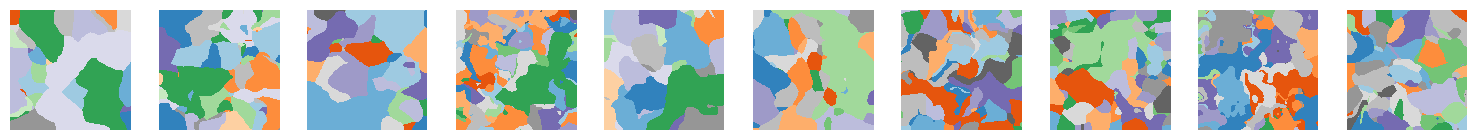

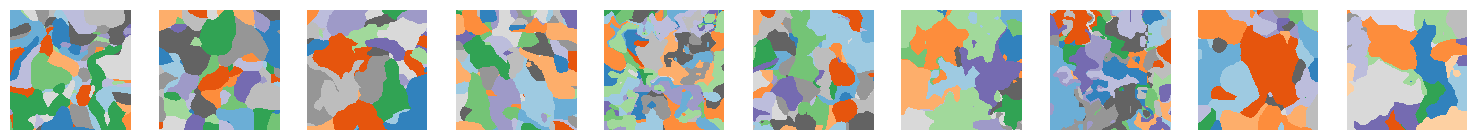

In [ ]:
# Input shapes.
in_shape = (256,) * 2
num_dim = len(in_shape)
num_label = 16
num_maps = 40

# Shape generation.
label_maps = []
for _ in tqdm.tqdm(range(num_maps)):
  # Draw image and warp.
  im = ne.utils.augment.draw_perlin(
    out_shape=(*in_shape, num_label),
    scales=(32, 64), max_std=1,
  )
  warp = ne.utils.augment.draw_perlin(
    out_shape=(*in_shape, num_label, num_dim),
    scales=(16, 32, 64), max_std=16,
  )

  # Transform and create label map.
  im = vxm.utils.transform(im, warp)
  lab = tf.argmax(im, axis=-1)
  label_maps.append(np.uint8(lab))


# Visualize shapes.
num_row = 2
per_row = 10
for i in range(0, num_row * per_row, per_row):
  ne.plot.slices(label_maps[i:i + per_row], cmaps=['tab20c'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


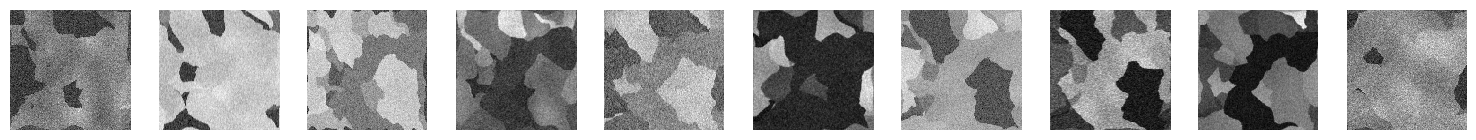

In [ ]:
# Training-image generation. For accurate registration, the landscape of warps
# and image contrasts will need to include the target distribution.
prop = dict(
  in_shape=in_shape,
  labels_in=range(num_label),
  warp_max=4,
  warp_blur_min=(8, 8),
  warp_blur_max=(64, 64),
)
model_gen_1 = ne.models.labels_to_image(**prop, id=1)
model_gen_2 = ne.models.labels_to_image(**prop, id=2)


# Test repeatedly on the same input.
num_gen = 10
input = np.expand_dims(label_maps[0], axis=(0, -1))
slices = [model_gen_1.predict(input)[0] for _ in range(num_gen)]
ne.plot.slices(slices);

In [ ]:
# Registration model.
model_def = vxm.networks.VxmDense(
  inshape=in_shape,
  int_resolution=2,
  svf_resolution=2,
  nb_unet_features=([256] * 4, [256] * 8),
  reg_field='warp',
)


# Moved labels.
ima_1, map_1 = model_gen_1.outputs
ima_2, map_2 = model_gen_2.outputs

_, warp = model_def((ima_1, ima_2))
moved = vxm.layers.SpatialTransformer(fill_value=0)((map_1, warp))


# Contrast invariance: MSE loss on probability maps.
class AddLoss(tf.keras.layers.Layer):
  def call(self, x):
    moved, map_2, warp = x
    const = tf.zeros((tf.shape(moved)[0], 1))
    self.add_loss(vxm.losses.MSE().loss(moved, map_2) + const)
    self.add_loss(vxm.losses.Grad('l2', loss_mult=0.05).loss(None, warp))
    return x


# Combined model: synthesis and registration.
inputs = (*model_gen_1.inputs, *model_gen_2.inputs)
model = tf.keras.Model(inputs, AddLoss()((moved, map_2, warp)))
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - loss: 0.0274
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0298
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0279


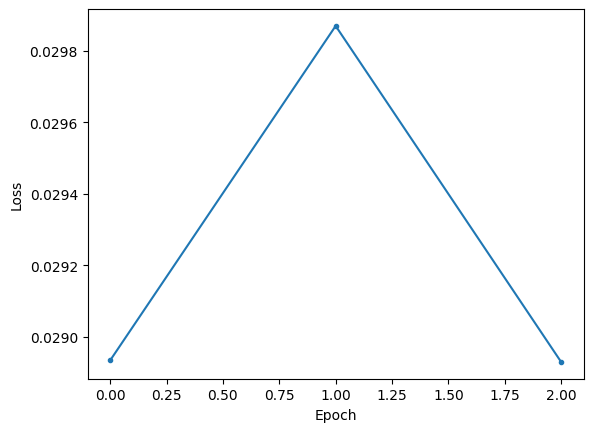

In [ ]:
# Training. Re-running the cell will continue training.
hist = model.fit(
  vxm.generators.synthmorph(label_maps, same_subj=True, flip=True),
  epochs=3,
  steps_per_epoch=100,
)


# Visualize loss.
plt.plot(hist.epoch, hist.history['loss'], '.-')
plt.xlabel('Epoch')
plt.ylabel('Loss');

In [ ]:
# Skip training, download model weights.
!gdown -cO weights.h5 19ayDE-otx2kTcGzEhz_pv9MjnJkpX638
model.load_weights('weights.h5')

Downloading...
From: https://drive.google.com/uc?id=19ayDE-otx2kTcGzEhz_pv9MjnJkpX638
To: /content/weights.h5
100% 33.2M/33.2M [00:00<00:00, 88.1MB/s]


In [ ]:
# Resize and normalize test images.
def conform(x, in_shape=in_shape):
  x = np.float32(x)
  x = np.squeeze(x)
  x = ne.utils.minmax_norm(x)
  x = ne.utils.zoom(x, zoom_factor=[o / i for o, i in zip(in_shape, x.shape)])
  return x[None, ..., None]


def register(moving, fixed):
  # Conform and register.
  moving = conform(moving)
  fixed = conform(fixed)
  moved, warp = model_def.predict((moving, fixed), verbose=0)

  # Visualize.
  slices = (moving, fixed, moved, warp[..., 0])
  titles = ('Moving', 'Fixed', 'Moved', 'Warp (x-axis)')
  ne.plot.slices(slices, titles, do_colorbars=True)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


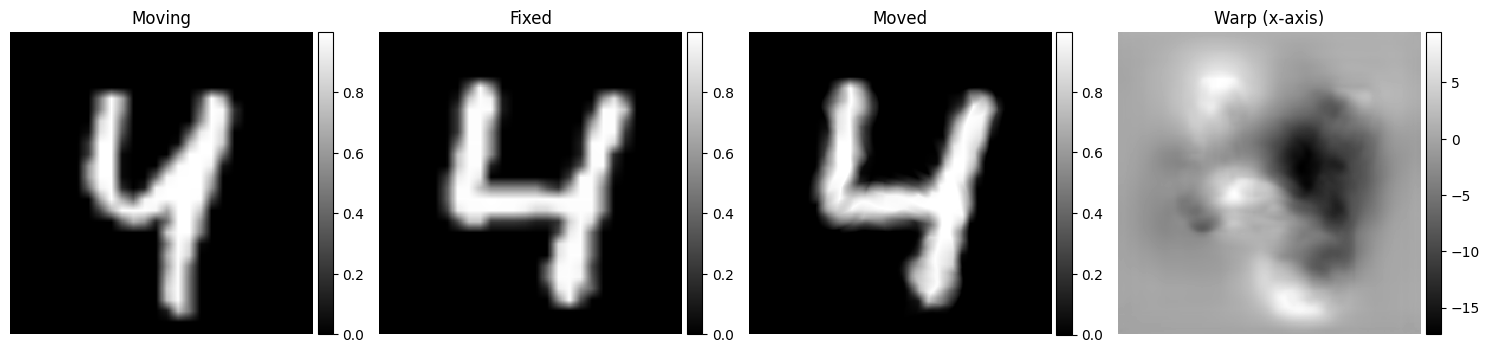

In [ ]:
# Test on MNIST.
images, digits = tf.keras.datasets.mnist.load_data()[-1]
ind = np.flatnonzero(digits == 4)
register(moving=images[ind[6]], fixed=images[ind[9]])

Cached dataset in /root/.neurite.


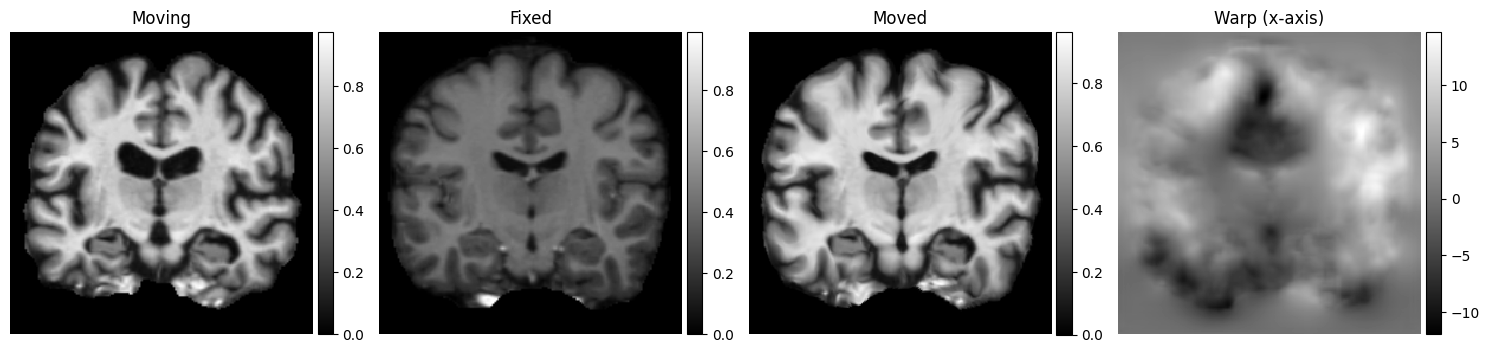

In [ ]:
# Test on OASIS-1.
images = ne.py.data.load_dataset('2D-OASIS-TUTORIAL')
register(moving=images[2], fixed=images[7])

In [ ]:
# Package versions.
!pip freeze

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.10.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.12.15
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.10.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.7.2
arviz==0.22.0
astropy==7.1.0
astropy-iers-data==0.2025.8.18.0.40.14
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
Authlib==1.6.1
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.21.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.15.0
bigquery-magics==0.10.2
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.0.0
blosc2==3.7.1
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.8.3
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.3
chex==0.1.90
clarabel==0.11.1
click==8.2.1
cl